In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

In [2]:
df = pd.read_csv('data/city_temperature.csv', low_memory=False)
df.head()

,Region,Country,State,City,Month,Day,Year,AvgTemperature
0,Africa,Algeria,NaN,Algiers,1,1,1995,64.2
1,Africa,Algeria,NaN,Algiers,1,2,1995,49.4
2,Africa,Algeria,NaN,Algiers,1,3,1995,48.8
3,Africa,Algeria,NaN,Algiers,1,4,1995,46.4
4,Africa,Algeria,NaN,Algiers,1,5,1995,47.9


In [3]:
print(f"Total Observations (rows): {df.shape[0]}")
print(f"Total Features (columns): {df.shape[1]}")

Total Observations (rows): 2906327
Total Features (columns): 8


In [4]:
print("Columns : ", list(df.columns))

Columns :  ['Region', 'Country', 'State', 'City', 'Month', 'Day', 'Year', 'AvgTemperature']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2906327 entries, 0 to 2906326
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Region          str    
 1   Country         str    
 2   State           str    
 3   City            str    
 4   Month           int64  
 5   Day             int64  
 6   Year            int64  
 7   AvgTemperature  float64
dtypes: float64(1), int64(3), str(4)
memory usage: 259.4 MB


In [6]:
#Check for Duplicate Values
duplicate_count = df.duplicated().sum()

if (duplicate_count>0):
    print(f"Before: {df.shape[0]}")
    print(f"{duplicate_count} Duplicate values found in the data.")
    df.drop_duplicates(inplace=True)
    print(f"After: {df.shape[0]}")
else:
    print("No duplicate values detected in the data.")

Before: 2906327
20715 Duplicate values found in the data.
After: 2885612


In [7]:
def check_data_summary(data: pd.DataFrame) -> pd.DataFrame:
    missing = data.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    return pd.DataFrame({"count": missing, "percent": round(missing / data.shape[0] * 100, 2)})

check_data_summary(df)

,count,percent
State,1448805,50.21


In [8]:
df.drop(columns=["State"], inplace=True)

In [9]:
print("GEOGRAPHIC COVERAGE")
print(f" Regions   : {df['Region'].nunique()}")
print(f" Countries : {df['Country'].nunique()}")
print(f" Cities    : {df['City'].nunique()}")

print("\nTIME SPAN")
print(f" Days   : {df['Day'].min()} - {df['Day'].max()}")
print(f" Months : {df['Month'].min()} - {df['Month'].max()}")
print(f" Years  : {df['Year'].min()} - {df['Year'].max()}")

GEOGRAPHIC COVERAGE
 Regions   : 7
 Countries : 125
 Cities    : 321

TIME SPAN
 Days   : 0 - 31
 Months : 1 - 12
 Years  : 200 - 2020


In [10]:
day_zero = df[df["Day"] == 0]

print(f"Rows with Day = 0 : {len(day_zero)}")
print(f"Percentage        : { round(len(day_zero) / len(df) * 100, 5)}%")

Rows with Day = 0 : 8
Percentage        : 0.00028%


In [11]:
df = df[df["Day"] != 0]

In [12]:
print("Year values : ", df["Year"].unique())

Year values :  [1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008
 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020  201  200]


In [13]:
year_200_201 = df[(df["Year"] == 200) | (df["Year"] == 201)]

print(f"Rows with Year = 200 or 201 : {len(year_200_201)}")
print(f"Percentage        : { round(len(year_200_201) / len(df) * 100, 5)}%")

Rows with Year = 200 or 201 : 295
Percentage        : 0.01022%


In [14]:
df = df[df["Year"] >= 1995]

In [15]:
df["AvgTemperature"] = 5/9 * (df["AvgTemperature"] - 32)

df.tail()

,Region,Country,City,Month,Day,Year,AvgTemperature
2906322,North America,US,San Juan Puerto Rico,7,27,2013,28.000000
2906323,North America,US,San Juan Puerto Rico,7,28,2013,27.555556
2906324,North America,US,San Juan Puerto Rico,7,29,2013,29.000000
2906325,North America,US,San Juan Puerto Rico,7,30,2013,28.777778
2906326,North America,US,San Juan Puerto Rico,7,31,2013,28.666667


In [16]:
avg_by_region = df.groupby("Region")["AvgTemperature"].mean()

avg_by_region

Region
Africa                               12.013147
Asia                                 16.982584
Australia/South Pacific              16.211594
Europe                                8.273159
Middle East                          20.213641
North America                        12.926749
South/Central America & Carribean    16.772726
Name: AvgTemperature, dtype: float64

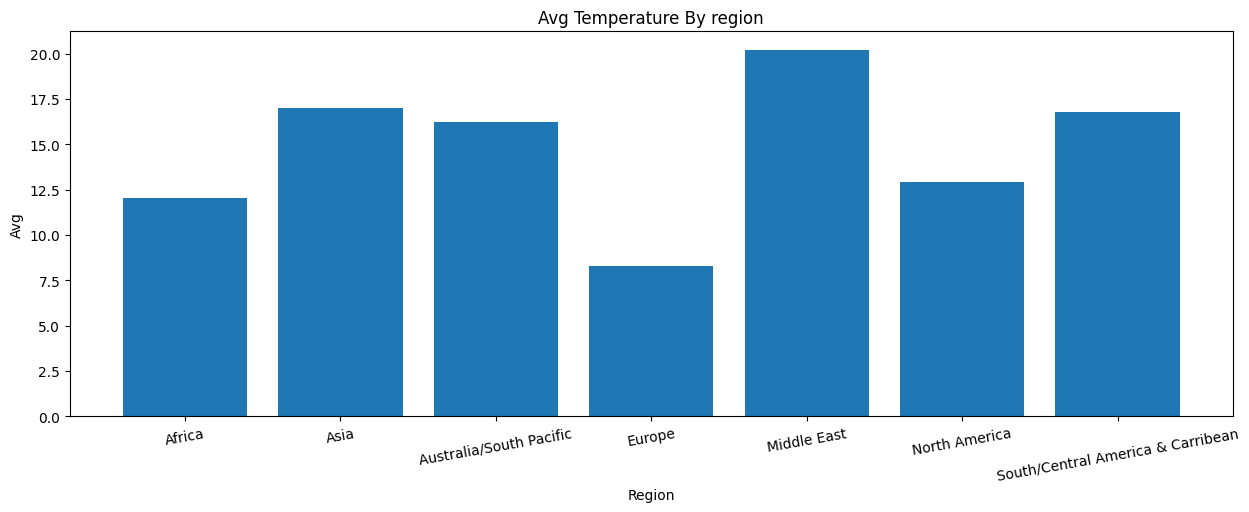

In [17]:
plt.figure(figsize=(15, 5))
plt.bar(avg_by_region.index, avg_by_region.values)
plt.title('Avg Temperature By region')
plt.xlabel('Region')
plt.ylabel('Avg')
plt.xticks(rotation=10)
plt.show()

In [18]:
df_sorted_by_temp = df.sort_values("AvgTemperature", ascending=True)

In [19]:
df_sorted_by_temp.head(3)

,Region,Country,City,Month,Day,Year,AvgTemperature
148781,Africa,Mozambique,Maputo,12,25,2000,-72.777778
207783,Africa,Togo,Lome,12,21,1996,-72.777778
207785,Africa,Togo,Lome,12,23,1996,-72.777778


In [20]:
df_sorted_by_temp.tail(3).sort_values("AvgTemperature", ascending=False)

,Region,Country,City,Month,Day,Year,AvgTemperature
1034962,Middle East,Kuwait,Kuwait,8,1,2012,43.333333
1032390,Middle East,Kuwait,Kuwait,7,17,2005,43.277778
1034963,Middle East,Kuwait,Kuwait,8,2,2012,43.277778


In [21]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [22]:
train_df["IsTrain"] = 1
test_df["IsTrain"] = 0

In [23]:
def get_iqr_bounds(group) -> pd.Series:
    """Calculates lower and upper IQR bounds for a group."""
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return pd.Series({'lower_bound': lower_bound, 'upper_bound': upper_bound})

seasonal_bounds = train_df.groupby(['Country', 'Month'])['AvgTemperature'].apply(get_iqr_bounds).unstack().reset_index()

print(seasonal_bounds.head())

   Country  Month  lower_bound  upper_bound
0  Albania      1    -9.291667    19.708333
1  Albania      2    -6.236111    20.097222
2  Albania      3    -0.111111    21.111111
3  Albania      4     4.638889    22.638889
4  Albania      5     7.000000    28.777778


In [24]:
df = pd.concat([train_df, test_df], ignore_index=True)
df.head()

,Region,Country,City,Month,Day,Year,AvgTemperature,IsTrain
0,North America,Canada,Toronto,9,1,2013,21.611111,1
1,North America,US,Sault Ste Marie,9,3,1995,16.111111,1
2,Europe,Spain,Barcelona,10,22,1999,18.944444,1
3,North America,US,Tucson,7,10,1995,34.277778,1
4,North America,US,Caribou,1,17,2017,-5.777778,1


In [25]:
def apply_iqr_filter(df: pd.DataFrame, bounds: pd.DataFrame) -> pd.DataFrame:
    """Filter dataset using precomputed IQR bounds."""

    merged = df.merge(bounds, on=["Country", "Month"], how="left")

    filtered_df = merged[
        (merged["AvgTemperature"] >= merged["lower_bound"]) &
        (merged["AvgTemperature"] <= merged["upper_bound"])
    ].copy()

    filtered_df.drop(columns=["lower_bound", "upper_bound"], inplace=True)

    return filtered_df

In [26]:
df = apply_iqr_filter(df, seasonal_bounds)

In [27]:
df["Date"] = pd.to_datetime(df[["Year", "Month", "Day"]])
df = df.sort_values("Date")
df.head()

,Region,Country,City,Month,Day,Year,AvgTemperature,IsTrain,Date
2477349,Europe,Cyprus,Nicosia,1,1,1995,-72.777778,0,1995-01-01
793093,North America,US,Tupelo,1,1,1995,8.722222,1,1995-01-01
1005607,Asia,Taiwan,Taipei,1,1,1995,16.166667,1,1995-01-01
305480,North America,US,Charlotte,1,1,1995,5.500000,1,1995-01-01
923020,North America,US,Rhode Island,1,1,1995,3.888889,1,1995-01-01


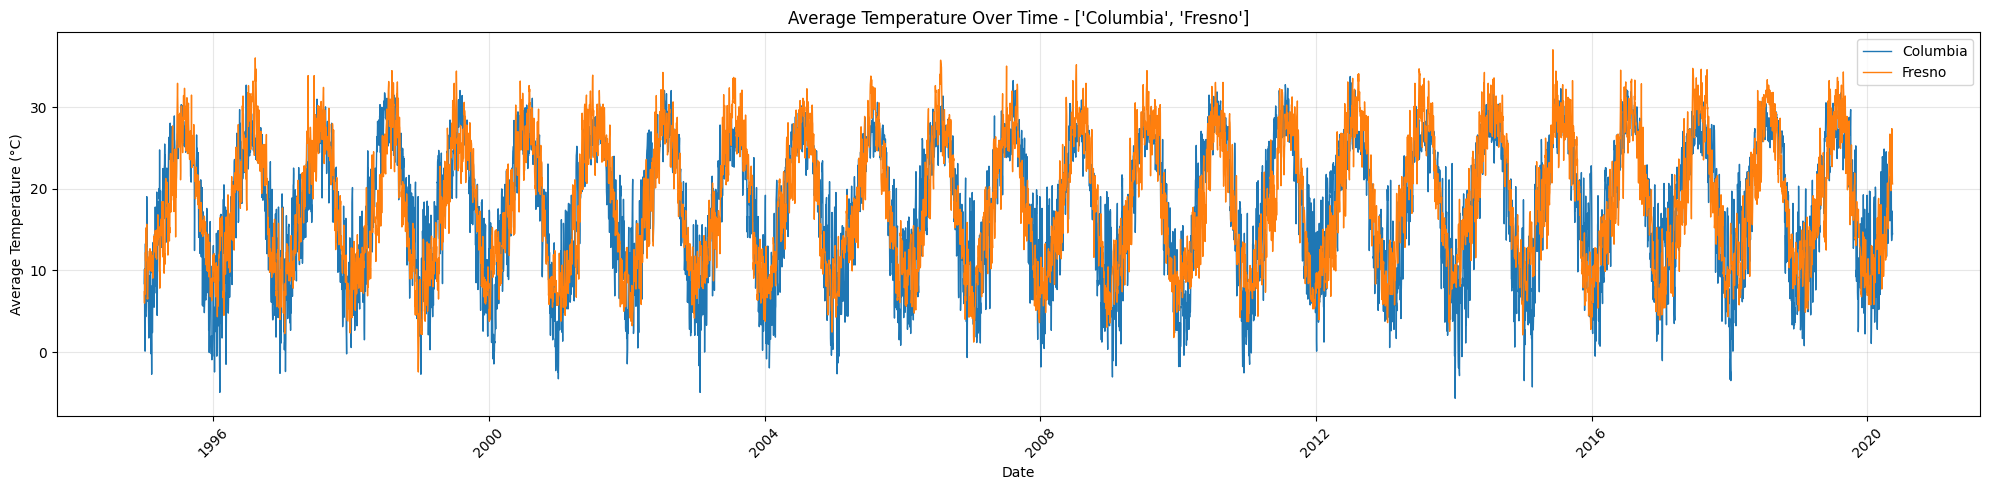

In [28]:
cities = ["Columbia", "Fresno"]
plt.figure(figsize=(20, 5))

for city in cities:
    city_df = df[df["City"] == city].copy()

    plt.plot(city_df["Date"], city_df["AvgTemperature"], linewidth=1, label=city)

plt.title(f"Average Temperature Over Time - {cities}")
plt.xlabel("Date")
plt.ylabel("Average Temperature (°C)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
train_df = df[df["IsTrain"] == 1].drop(columns=["IsTrain"])
test_df = df[df["IsTrain"] == 0].drop(columns=["IsTrain"])

In [30]:
X_train = train_df.drop(columns=["AvgTemperature", "Date"]) 
y_train = train_df["AvgTemperature"]
X_test = test_df.drop(columns=["AvgTemperature", "Date"]) 
y_test = test_df["AvgTemperature"]

In [31]:
for col in ['Region', 'Country', 'City']:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

In [32]:
model = xgb.XGBRegressor(
    enable_categorical=True,
    tree_method='hist',
    n_estimators=100,
    max_depth=6
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [33]:
y_pred = model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'MSE: {mse:.3f}')
print(f'MAE: {mae:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 6.644
MSE: 44.148
MAE: 3.241
R²: 0.791


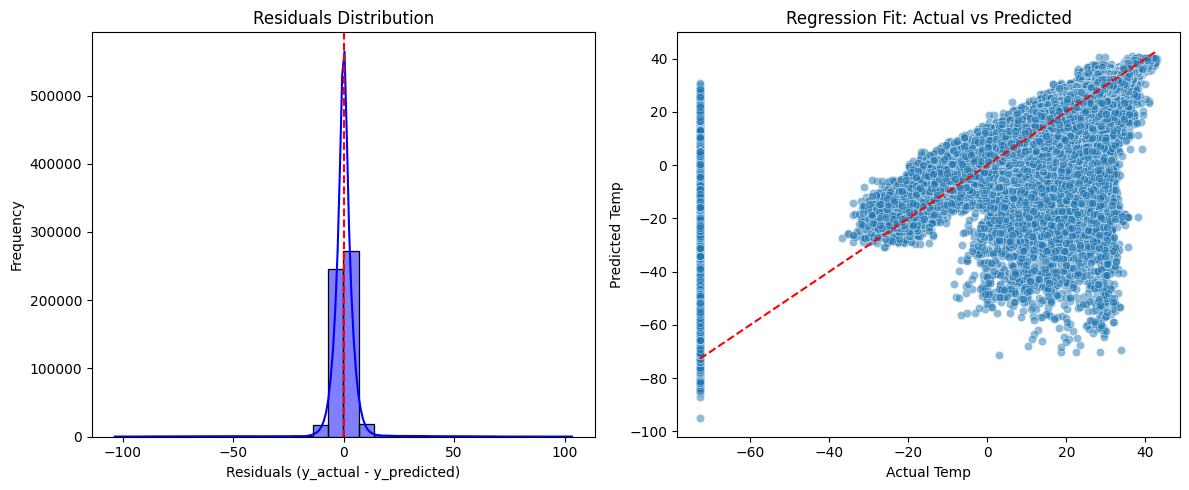

In [34]:
residuals = y_test - y_pred

plt.figure(figsize=(12,5))


# Plot 1: Residuals Distribution.
plt.subplot(1,2,1)
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (y_actual - y_predicted)")
plt.ylabel("Frequency")


# Plot 2: Regression Fit (Actual vs Predicted).
plt.subplot(1,2,2)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title("Regression Fit: Actual vs Predicted")
plt.xlabel("Actual Temp")
plt.ylabel("Predicted Temp")


# Show plots.
plt.tight_layout()
plt.show()



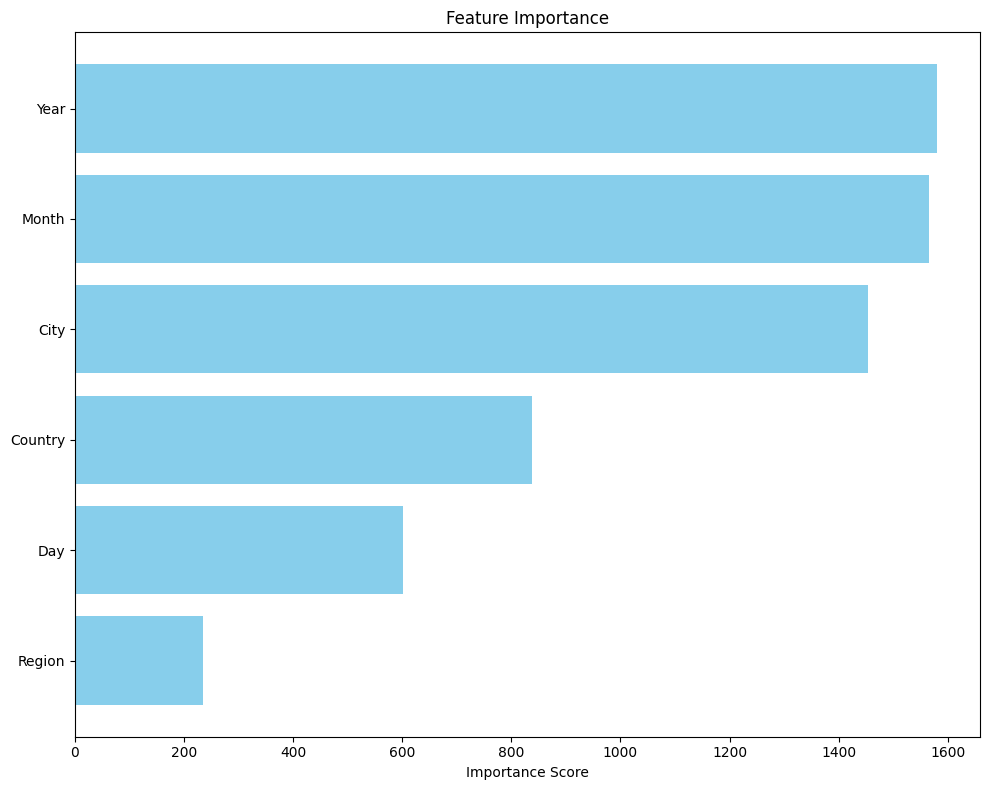

In [35]:
importance = model.get_booster().get_score(importance_type='weight')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['Feature'][::-1],
    importance_df['Importance'][::-1],
    color='skyblue'
)
plt.xlabel('Importance Score')
plt.title(f'Feature Importance')
plt.tight_layout()
plt.show()

In [36]:

future_df = pd.DataFrame({
    'Region': ["North America", "North America"],
    'Country': ["US", "US"],
    'City': ["Albany", "Albany"],
    'Month': [6, 6],
    'Day': [16, 15],
    'Year': [2026, 2026]
})

for col in ['Region', 'Country', 'City']:
    future_df[col] = future_df[col].astype(
        pd.CategoricalDtype(categories=X_train[col].cat.categories)
    )

future_pred = model.predict(future_df)
y_true = [18, 21]
y_pred = model.predict(future_df)

for date, actual, pred in zip(future_df['Day'], y_true, y_pred):
    print(f"Day {date}: actual={actual}°C, predicted={pred:.2f}°C, error={pred-actual:+.2f}")

mae_future = mean_absolute_error(y_true, y_pred)
print(f"MAE: {mae_future:.3f}")

Day 16: actual=18°C, predicted=16.73°C, error=-1.27
Day 15: actual=21°C, predicted=16.64°C, error=-4.36
MAE: 2.817


In [68]:
SEARCH_SPACE = {
    'max_depth':        (3, 10),
    'learning_rate':    (0.01, 0.3),
    'min_child_weight': (1, 10),
    'subsample':        (0.5, 1.0),
    'colsample_bytree': (0.5, 1.0),
    'gamma':            (0, 5),
    'reg_alpha':        (0, 5),
    'reg_lambda':       (0, 5),
}

DATA = {"X_train": X_train, "X_test": X_test, "y_train": y_train, "y_test": y_test}
POPULATION_SIZE = 10
GENERATIONS = 20
CROSSOVER_PROB = 0.9
MUTATION_PROB = 0.2

np.random.seed(42)

In [65]:
def initialize_population(search_space: dict[str, tuple[float, float]], population_size: int) -> list[dict[str, float]]:
    return [{key: np.random.uniform(value[0], value[1]) for key, value in search_space.items()} for i in range(population_size)]

def tournament_selection(population: list[dict[str, float]], fitness: list[float], k: int):
    selected = []
    for _ in range(len(population)):
        idxes = np.random.choice(len(population), k, replace=False)
        max_idx, max_fitness = -1, -float('inf') 
        for idx in idxes:
            if fitness[idx] > max_fitness:
                max_idx, max_fitness = idx, fitness[idx]

        selected.append(population[max_idx])

    return selected

def mutate(config: dict[str, float], mutation_prob: float, search_space: dict[str, tuple[float, float]]) -> dict[str, float]:
    mutated_config = config.copy()
    mask = np.random.rand(len(mutated_config)) < mutation_prob
    genes = [items for i, items in enumerate(mutated_config.items()) if mask[i]]
    new_genes = [(key, np.clip(value + np.random.normal(0, 0.1), search_space[key][0], search_space[key][1])) for key, value in genes]

    for key, value in new_genes:
        mutated_config[key] = value
    
    return mutated_config

def crossover(config1: dict[str, float], config2: dict[str, float]) -> tuple[dict[str, float], dict[str, float]]:
    crossover_point = np.random.randint(1, len(config1))
    child1, child2 = {}, {}

    for i, key in enumerate(config1.keys()):
        if i < crossover_point:
            child1[key] = config1[key]
            child2[key] = config2[key]
        else:
            child1[key] = config2[key]
            child2[key] = config1[key]
    
    return child1, child2

def fitness(config: dict[str, float], data: dict[str, np.ndarray]) -> float:
    model_config = config.copy()
    for int_param in ['max_depth', 'n_estimators', 'min_child_weight']:
        if int_param in model_config:
            model_config[int_param] = int(round(model_config[int_param]))

    model = xgb.XGBRegressor(
        enable_categorical=True,
        tree_method='hist',
        n_estimators=300,
        eval_metric='rmse',
        **model_config
    )

    model.fit(data["X_train"], data["y_train"])
    rmse = root_mean_squared_error(data["y_test"], model.predict(data["X_test"]))

    return -rmse

In [ ]:
def genetic_algorithm(data, search_space, population_size=10, generations=5, mutation_prob=0.1, crossover_prob=0.8):
    population = initialize_population(search_space=search_space, population_size=population_size)

    best_parameters = None
    best_score = -float('inf')
    best_scores = []

    for generation in range(generations):
        fitness_scores = [fitness(config, data) for config in population]
        
        gen_best_score = max(fitness_scores)
        
        if gen_best_score > best_score:
            best_score = gen_best_score
            best_parameters = population[fitness_scores.index(gen_best_score)].copy()
        best_scores.append(-best_score)
        print(f"Generation {generation + 1}/{generations} | Best overall RMSE: {-best_score:.4f} | Parameters: {best_parameters}")

        parents = tournament_selection(population=population, fitness=fitness_scores, k=3)
        offspring = []
        np.random.shuffle(parents)

        for i in range(0, population_size, 2):
            if i + 1 >= len(parents):
                offspring.append(mutate(parents[i], mutation_prob, search_space))
                break

            if np.random.rand() < crossover_prob:
                c1, c2 = crossover(parents[i], parents[i + 1])
            else:
                c1, c2 = parents[i], parents[i + 1]
            
            offspring.extend([mutate(c1, mutation_prob, search_space), mutate(c2, mutation_prob, search_space)])
            
        population = offspring[:population_size]
        
    return best_parameters, best_scores

In [74]:
best_parameters, best_scores = genetic_algorithm(data=DATA,
                                               search_space=SEARCH_SPACE,
                                               population_size=POPULATION_SIZE,
                                               generations=GENERATIONS,
                                               mutation_prob=MUTATION_PROB,
                                               crossover_prob=CROSSOVER_PROB
                            )

Generation 1/20 | Best overall RMSE: 6.3710 | Parameters: {'max_depth': 9.785117749333693, 'learning_rate': 0.16169837480934315, 'min_child_weight': 6.664587743217362, 'subsample': 0.8478743444923086, 'colsample_bytree': 0.7272705323838866, 'gamma': 3.137790400420317, 'reg_alpha': 2.921571559615501, 'reg_lambda': 4.505790052454945}
Generation 2/20 | Best overall RMSE: 6.3600 | Parameters: {'max_depth': 9.785117749333693, 'learning_rate': 0.16169837480934315, 'min_child_weight': 6.664587743217362, 'subsample': 0.8478743444923086, 'colsample_bytree': 0.7272705323838866, 'gamma': np.float64(3.224397452024597), 'reg_alpha': 2.1211100462348815, 'reg_lambda': 4.53177192547368}
Generation 3/20 | Best overall RMSE: 6.3600 | Parameters: {'max_depth': 9.785117749333693, 'learning_rate': 0.16169837480934315, 'min_child_weight': 6.664587743217362, 'subsample': 0.8478743444923086, 'colsample_bytree': 0.7272705323838866, 'gamma': np.float64(3.224397452024597), 'reg_alpha': 2.1211100462348815, 'reg_l

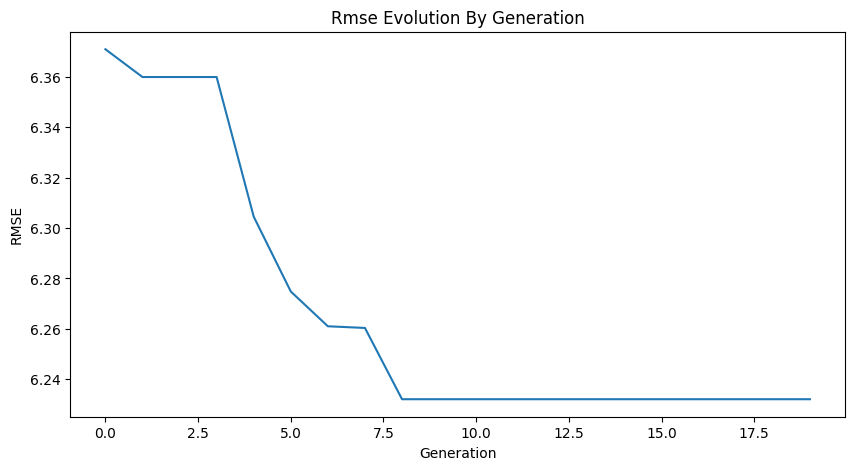

In [77]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(best_scores)), best_scores)
plt.xlabel("Generation")
plt.ylabel("RMSE")
plt.title("Rmse Evolution By Generation")
plt.show()


In [78]:
best_parameters

{'max_depth': np.float64(9.502229694212124),
 'learning_rate': np.float64(0.13728271128027827),
 'min_child_weight': np.float64(6.7624770972086345),
 'subsample': np.float64(1.0),
 'colsample_bytree': np.float64(1.0),
 'gamma': np.float64(2.9681229129306357),
 'reg_alpha': np.float64(2.1159341477643516),
 'reg_lambda': 4.53177192547368}

In [81]:
model_config = best_parameters.copy()
for int_param in ['max_depth', 'n_estimators', 'min_child_weight']:
    if int_param in model_config:
        model_config[int_param] = int(round(model_config[int_param]))

final_model = xgb.XGBRegressor(
        enable_categorical=True,
        tree_method='hist',
        n_estimators=300,
        eval_metric='rmse',
        **model_config
    )

final_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,np.float64(1.0)
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import loa

In [83]:
y_pred = final_model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'MSE: {mse:.3f}')
print(f'MAE: {mae:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 6.232
MSE: 38.838
MAE: 2.867
R²: 0.816
